# 01 — Data exploration

**Project:** UK DB pension funding and longevity model
**Created:** 30 July 2026

Purpose: load the ONS National Life Tables and the Bank of England
nominal gilt spot curve into clean pandas DataFrames, inspect their
structure, and plot both raw. No modelling - this notebook exists
to understand the data before building anything on it.

HMD mortality data is handled separately in a later notebook (Lee-Carter).

Data files are in `data/raw/` and are gitignored - see `notes.md` for
sources and retrieval.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys


## Setup

Imports and the path to `data/raw/`. All file references below use `DATA_RAW`.

In [2]:
from pathlib import Path

DATA_RAW = Path("..") / "data" / "raw"

print(DATA_RAW.resolve())
print([f.name for f in DATA_RAW.iterdir()])

/Users/jeevanbajra/db-pensions-model/data/raw
['Mx_1x1.txt', '~$GLC_nominal_daily_current_month.xlsx', 'nltuk198020223.xlsx', 'GLC_nominal_daily_current_month.xlsx']


## ONS National Life Tables

Loading the 2022-2024 period sheet - most recent available, and it
excludes 2020 and 2021, which carry severe pandemic excess mortality
(decision D2 in `notes.md`).
Males and females sit side by side on one sheet, so they're read
separately and combined. Check target: life expectancy at birth
should match the published 79.12 (M) and 83.02 (F).

In [3]:
ons_m = (pd.read_excel(DATA_RAW / "nltuk198020223.xlsx", sheet_name="2022-2024", header=5, usecols="A:F"))
ons_f = (pd.read_excel(DATA_RAW / "nltuk198020223.xlsx", sheet_name="2022-2024", header=5, usecols="H:M"))
ons_f.columns = ["age", "mx", "qx", "lx", "dx", "ex"]
ons_m["sex"]= "M"
ons_f["sex"]= "F"

In [4]:
(ons_m.shape)
print(ons_m.dtypes)
ons_m.head() 

age      int64
mx     float64
qx     float64
lx     float64
dx     float64
ex     float64
sex        str
dtype: object


,age,mx,qx,lx,dx,ex,sex
0,0,0.004612,0.004602,100000.0,460.2,79.12,M
1,1,0.000247,0.000247,99539.8,24.6,78.49,M
2,2,0.000177,0.000177,99515.3,17.6,77.51,M
3,3,0.000115,0.000115,99497.6,11.4,76.52,M
4,4,0.000100,0.000100,99486.2,9.9,75.53,M


In [5]:
print(ons_f.shape)
print(ons_f.dtypes)
ons_f.head()

(101, 7)
age      int64
mx     float64
qx     float64
lx     float64
dx     float64
ex     float64
sex        str
dtype: object


,age,mx,qx,lx,dx,ex,sex
0,0,0.003638,0.003631,100000.0,363.1,83.02,F
1,1,0.000207,0.000206,99636.9,20.6,82.32,F
2,2,0.000137,0.000137,99616.3,13.7,81.34,F
3,3,0.000099,0.000099,99602.6,9.8,80.35,F
4,4,0.000081,0.000081,99592.8,8.1,79.36,F


In [6]:
ons = pd.concat([ons_m, ons_f], ignore_index=True)
print(ons)

     age        mx        qx        lx      dx     ex sex
0      0  0.004612  0.004602  100000.0   460.2  79.12   M
1      1  0.000247  0.000247   99539.8    24.6  78.49   M
2      2  0.000177  0.000177   99515.3    17.6  77.51   M
3      3  0.000115  0.000115   99497.6    11.4  76.52   M
4      4  0.000100  0.000100   99486.2     9.9  75.53   M
..   ...       ...       ...       ...     ...    ...  ..
197   96  0.285191  0.249600   10082.4  2516.6   2.86   F
198   97  0.315238  0.272316    7565.9  2060.3   2.65   F
199   98  0.350303  0.298092    5505.6  1641.2   2.45   F
200   99  0.376983  0.317194    3864.4  1225.8   2.28   F
201  100  0.422928  0.349105    2638.6   921.2   2.11   F

[202 rows x 7 columns]


In [7]:
print(ons["sex"].value_counts())
ons.tail()

sex
M    101
F    101
Name: count, dtype: int64


,age,mx,qx,lx,dx,ex,sex
197,96,0.285191,0.249600,10082.4,2516.6,2.86,F
198,97,0.315238,0.272316,7565.9,2060.3,2.65,F
199,98,0.350303,0.298092,5505.6,1641.2,2.45,F
200,99,0.376983,0.317194,3864.4,1225.8,2.28,F
201,100,0.422928,0.349105,2638.6,921.2,2.11,F


In [8]:
m = ons[ons["sex"] == "M"]
f = ons[ons["sex"] == "F"]

## Mortality by age

Plotted linear first, then on a log y-axis. The linear version is
uninformative below age 60 - mortality spans three orders of magnitude,
so the log scale is necessary rather than stylistic.

Features: infant mortality at age 0; minimum around age 8-10; the
accident hump at ages 18-25, larger for males; near-linear from
roughly age 35, which is the exponential growth Gompertz's law
describes. The male and female lines run parallel above 35 - a
constant ratio, not a constant difference.

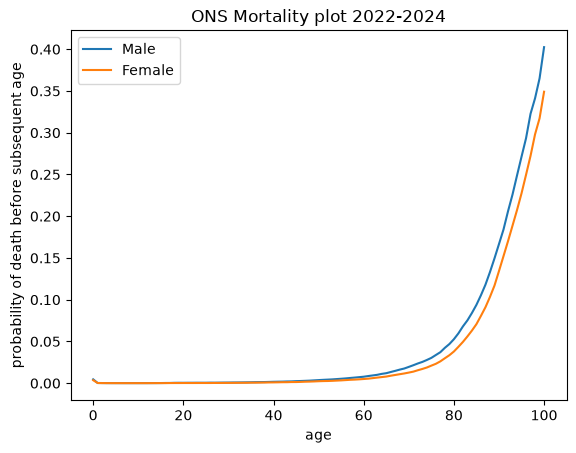

In [15]:
plt.plot( m["age"], m["qx"], label= "Male")
plt.plot( f["age"], f["qx"], label= "Female")

plt.title("ONS Mortality plot 2022-2024")
plt.xlabel("age")
plt.ylabel("probability of death before subsequent age")
plt.legend()
plt.show()

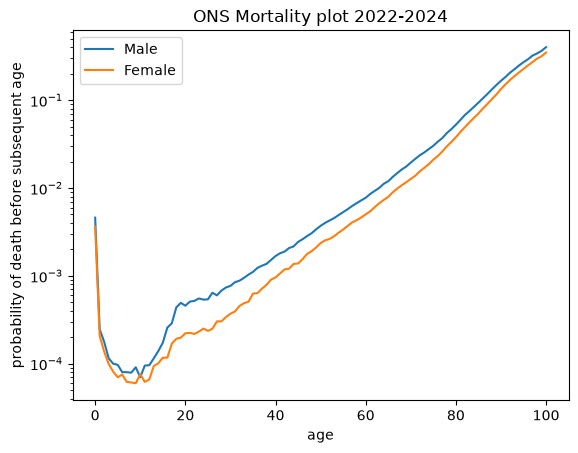

In [9]:
plt.plot( m["age"], m["qx"], label= "Male")
plt.plot( f["age"], f["qx"], label= "Female")
plt.yscale("log")
plt.title("ONS Mortality plot 2022-2024")
plt.xlabel("age")
plt.ylabel("probability of death before subsequent age")
plt.legend()
plt.show()

## Bank of England nominal gilt spot curve

Sheet `4. spot curve`, valuation date 28 July 2026 (decision D3).
The sheet has dates as rows and maturities as columns, so a single
date is selected and transposed. The `#VALUE!` row and the missing
0.5-year maturity are both removed.

Rates are percentages, continuously compounded -see flag F1.
No unit conversion here; that belongs in `src/discounting.py`.

In [10]:
boe = (pd.read_excel(DATA_RAW / "GLC_nominal_daily_current_month.xlsx", sheet_name="4. spot curve", header=3))
boe = boe.rename(columns={"years:": "date"})
boe = boe[boe["date"].notna()]
boe.head()

,date,0.5,1,1.5,2,2.5,3,3.5,4,4.5,...,35.5,36,36.5,37,37.5,38,38.5,39,39.5,40
1,2026-07-01,3.830912,3.979351,4.003203,4.023306,4.049729,4.082273,4.120019,4.162414,4.209030,...,5.523531,5.508837,5.493376,5.477162,5.460205,5.442519,5.424115,5.405006,5.385206,5.364728
2,2026-07-02,3.808362,3.954753,3.979898,4.002581,4.031900,4.067284,4.107675,4.152490,4.201305,...,5.536104,5.521354,5.505835,5.489560,5.472541,5.454789,5.436317,5.417138,5.397265,5.376713
3,2026-07-03,3.824472,3.967925,3.993078,4.016435,4.046373,4.082220,4.122953,4.168044,4.217105,...,5.546427,5.531686,5.516180,5.499921,5.482920,5.465190,5.446743,5.427592,5.407750,5.387230
4,2026-07-06,3.829316,3.964919,3.989272,4.013775,4.045188,4.082419,4.124349,4.170430,4.220282,...,5.563123,5.548282,5.532666,5.516286,5.499156,5.481287,5.462692,5.443385,5.423379,5.402688
5,2026-07-07,3.856013,3.994125,4.022620,4.050602,4.084439,4.123250,4.166138,4.212727,4.262761,...,5.597801,5.583046,5.567524,5.551247,5.534228,5.516478,5.498012,5.478842,5.458981,5.438444


In [11]:
row = boe[boe["date"] == pd.Timestamp("2026-07-28")]
row

,date,0.5,1,1.5,2,2.5,3,3.5,4,4.5,...,35.5,36,36.5,37,37.5,38,38.5,39,39.5,40
20,2026-07-28,NaN,4.122469,4.189886,4.238541,4.279196,4.317538,4.356276,4.396954,4.440343,...,5.665562,5.648958,5.631539,5.613318,5.59431,5.574528,5.553986,5.5327,5.510684,5.487954


In [12]:
row1 = row.drop(columns=["date"])
row2 = row1.T
row2.columns = ["spot_rate"]
row3 = row2.reset_index()
row4 = row3.rename(columns={"index": "maturity"})
curve = row4.dropna()
curve


,maturity,spot_rate
1,1.0,4.122469
2,1.5,4.189886
3,2.0,4.238541
4,2.5,4.279196
5,3.0,4.317538
...,...,...
75,38.0,5.574528
76,38.5,5.553986
77,39.0,5.532700
78,39.5,5.510684


## Gilt curve shape

The curve peaks in the mid-20s and slopes downward to 40 years.
This inversion is real market structure (flag F5) and matters for
the Day 11 extrapolation: holding the forward rate flat beyond 40
years will continue the downward slope rather than levelling off.

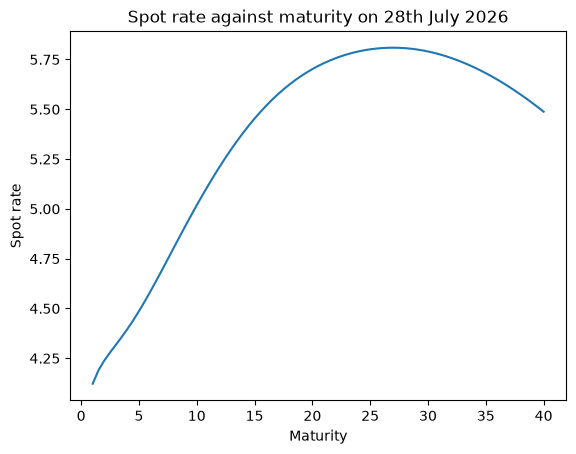

In [13]:
plt.plot( curve["maturity"], curve["spot_rate"])
plt.title("Spot rate against maturity on 28th July 2026")
plt.ylabel("Spot rate")
plt.xlabel("Maturity")
plt.show()